# 🌾 Crop Yield Prediction System
### Week 7 — Advanced Machine Learning Project

**Objective:** Predict expected crop yield (hg/hectare) from country, crop type, and weather data.

| | |
|---|---|
| **Models** | XGBoost Regressor · Random Forest Regressor · LightGBM |
| **Evaluation** | RMSE · MAE · R² Score |
| **Deployment** | Streamlit (UI) + FastAPI (REST API) |
| **Skills** | Advanced Regression · Forecasting · Feature Engineering |

---


## Table of Contents
1. [Setup & Imports](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Train / Test Split & Pipelines](#6)
7. [Model Training — Random Forest, XGBoost, LightGBM](#7)
8. [Model Evaluation (RMSE, MAE, R²)](#8)
9. [Feature Importance](#9)
10. [Hyperparameter Tuning (Best Model)](#10)
11. [Save Final Model for Deployment](#11)
12. [Inference Demo (single prediction)](#12)


## 1. Setup & Imports <a id='1'></a>

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MODEL_DIR = "../models"
IMAGE_DIR = "../images"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(IMAGE_DIR, name), dpi=150, bbox_inches="tight")

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 2. Load Dataset <a id='2'></a>

Target column is yield_tonnes_per_ha... a convenience yield_tonnes_per_ha column is also included (1 t/ha = 10,000 hg/ha)


In [32]:
df = pd.read_csv("../data/yield_df.csv")
print("Shape:", df.shape)
df.head()


Shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [34]:
df.describe()


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

In [63]:
print("Missing values:")
print(df.isna().sum())
print()
print("Countries:", df['Area'].nunique(), " | Crops:", df['Item'].nunique(),
      " | Years:", df['Year'].min(), "-", df['Year'].max())

print("Duplicate rows:")
duplicates = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", df.duplicated().sum())
print()

print(duplicates)


Missing values:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Countries: 101  | Crops: 10  | Years: 1990 - 2013
Duplicate rows:
Number of duplicate rows: 0

Empty DataFrame
Columns: [Unnamed: 0, Area, Item, Year, hg/ha_yield, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp]
Index: []


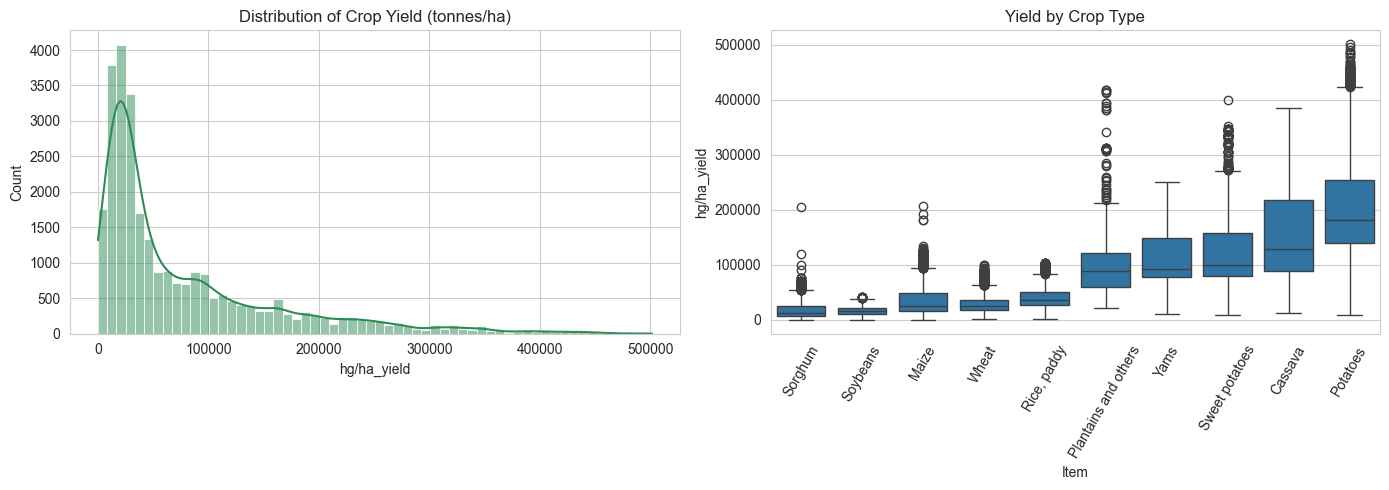

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["hg/ha_yield"], bins=60, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Distribution of Crop Yield (tonnes/ha)")

order = df.groupby("Item")["hg/ha_yield"].median().sort_values().index
sns.boxplot(data=df, x="Item", y="hg/ha_yield", order=order, ax=axes[1])
axes[1].set_title("Yield by Crop Type")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
savefig("01_yield_distribution_by_crop.png")
plt.show()


### Feature-target correlation 



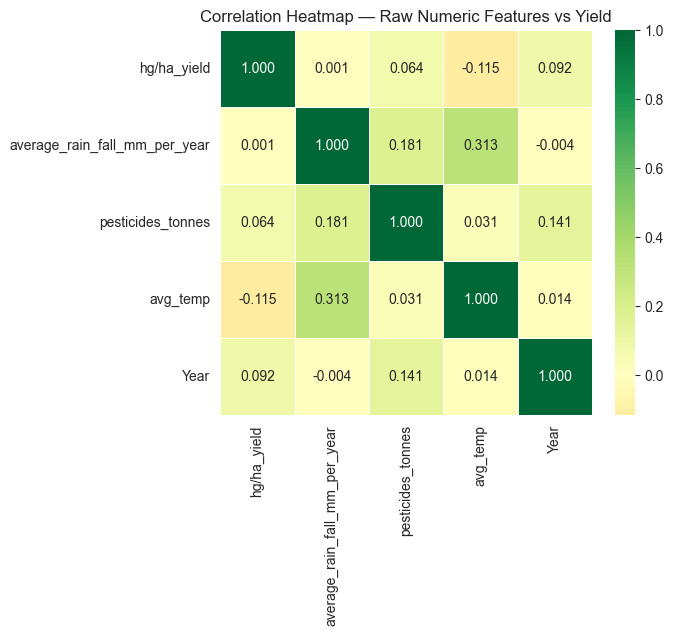

hg/ha_yield                      1.000000
Year                             0.091630
pesticides_tonnes                0.064085
average_rain_fall_mm_per_year    0.000962
avg_temp                        -0.114777
Name: hg/ha_yield, dtype: float64


In [39]:
numeric_cols = ["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp", "Year"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="RdYlGn", center=0, annot=True, fmt=".3f", linewidths=0.4)
plt.title("Correlation Heatmap — Raw Numeric Features vs Yield")
savefig("02_correlation_heatmap.png")
plt.show()

print(corr["hg/ha_yield"].sort_values(ascending=False))


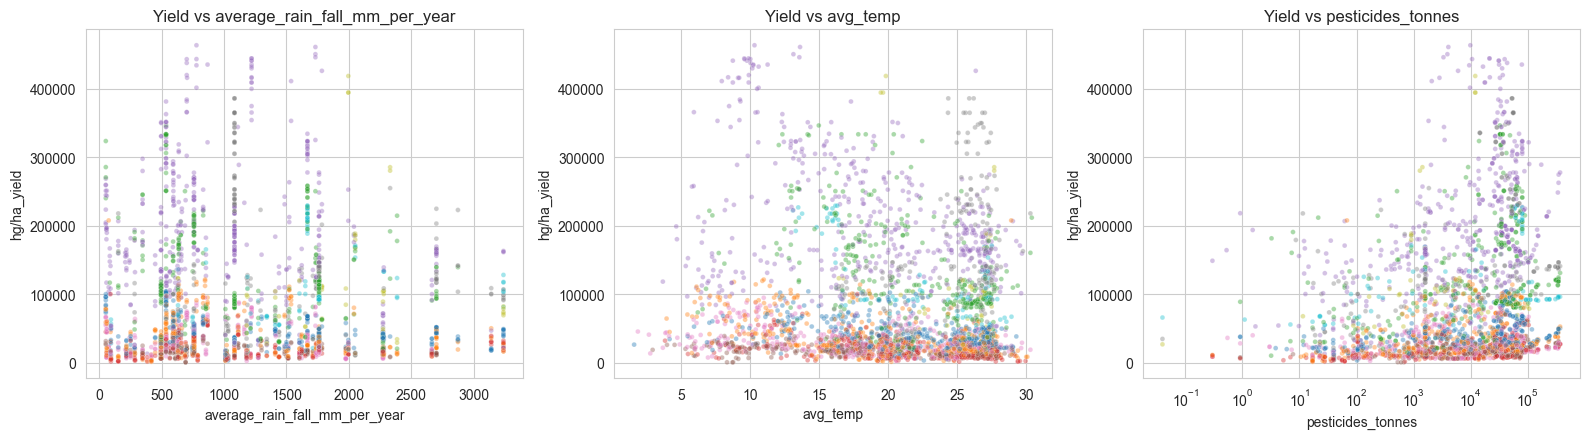

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]):
    sample = df.sample(min(3000, len(df)), random_state=1)
    sns.scatterplot(data=sample, x=col, y="hg/ha_yield", hue="Item",
                     alpha=0.4, s=12, ax=ax, legend=False)
    ax.set_title(f"Yield vs {col}")
    if col == "pesticides_tonnes":
        ax.set_xscale("log")
plt.tight_layout()
savefig("03_yield_vs_weather_scatter.png")
plt.show()


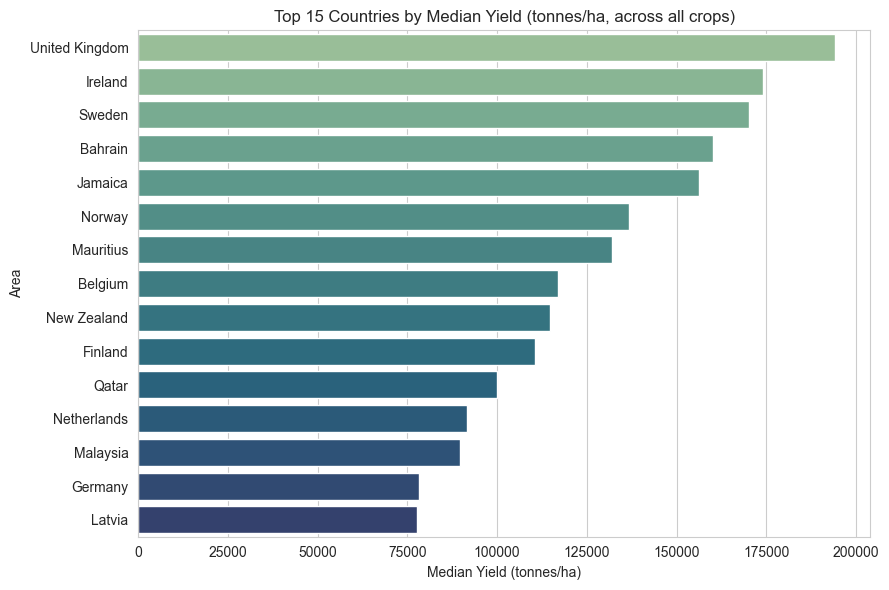

In [43]:
top_countries = df.groupby("Area")["hg/ha_yield"].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")
plt.title("Top 15 Countries by Median Yield (tonnes/ha, across all crops)")
plt.xlabel("Median Yield (tonnes/ha)")
plt.tight_layout()
savefig("04_top_countries_by_yield.png")
plt.show()


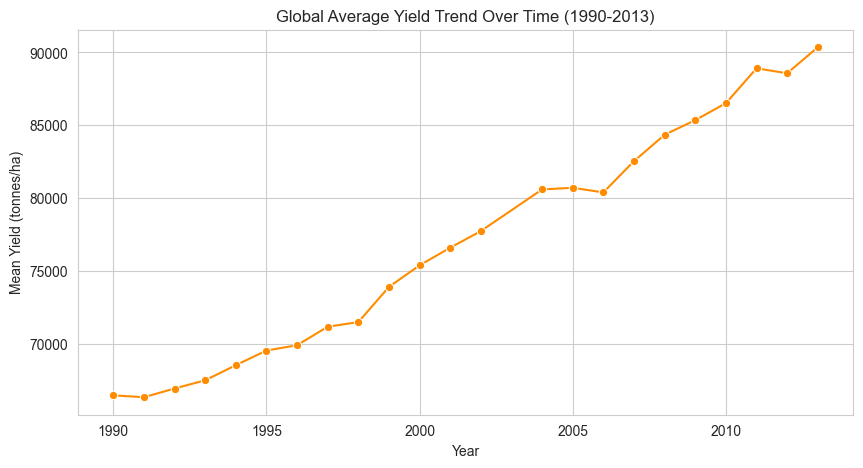

In [44]:
plt.figure(figsize=(10, 5))
yearly = df.groupby("Year")["hg/ha_yield"].mean()
sns.lineplot(x=yearly.index, y=yearly.values, marker="o", color="darkorange")
plt.title("Global Average Yield Trend Over Time (1990-2013)")
plt.ylabel("Mean Yield (tonnes/ha)")
savefig("05_yield_trend_over_time.png")
plt.show()


## 5. Feature Engineering <a id='5'></a>

With only three raw numeric predictors, we add a few derived features and let `country` + `crop`
(one-hot encoded) carry most of the signal, since Section 3 showed they're the dominant drivers:

- **`temp_rain_interaction`** — joint heat+moisture stress signal
- **`log_pesticides`** — `pesticides_tonnes` spans 4+ orders of magnitude (0.04 to 367,778); a log
  transform prevents a handful of huge-agriculture countries from dominating the scaled feature
- **`decade`** — coarser temporal bucket to help tree models pick up long-run trends
- **`years_since_1990`** — a simple linear time trend feature


In [47]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["temp_rain_interaction"] = data["avg_temp"] * data["average_rain_fall_mm_per_year"] / 1000
    data["log_pesticides"] = np.log1p(data["pesticides_tonnes"])
    data["decade"] = (data["Year"] // 10) * 10
    data["years_since_1990"] = data["Year"] - 1990
    return data

df_fe = engineer_features(df)
df_fe[["temp_rain_interaction", "log_pesticides", "decade", "years_since_1990"]].head()


,temp_rain_interaction,log_pesticides,decade,years_since_1990
0,24.30945,4.804021,1990,0
1,24.30945,4.804021,1990,0
2,24.30945,4.804021,1990,0
3,24.30945,4.804021,1990,0
4,24.30945,4.804021,1990,0


## 6. Train / Test Split & Preprocessing Pipeline <a id='6'></a>

In [48]:
TARGET = "hg/ha_yield"

numeric_features = [
    "average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes", "log_pesticides",
    "temp_rain_interaction", "Year", "years_since_1990",
]
categorical_features = ["Area", "Item"]

X = df_fe[numeric_features + categorical_features]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (22593, 9)  Test shape: (5649, 9)


In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 7. Model Training — Random Forest, XGBoost, LightGBM <a id='7'></a>

In [50]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=150, max_depth=12, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, objective="reg:squarederror"
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, max_depth=-1, num_leaves=63, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1
    ),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} trained ✅")


Random Forest trained ✅
XGBoost trained ✅
LightGBM trained ✅


## 8. Model Evaluation (RMSE, MAE, R²) <a id='8'></a>

All metrics are reported in the native `hg/ha` unit (FAO standard). Divide by 100,000 for tonnes/ha.


In [51]:
def evaluate(model, X_te, y_te, name):
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    return {"Model": name, "RMSE (hg/ha)": rmse, "MAE (hg/ha)": mae, "R2": r2}

results = [evaluate(pipe, X_test, y_test, name) for name, pipe in pipelines.items()]
results_df = pd.DataFrame(results).sort_values("RMSE (hg/ha)").reset_index(drop=True)
results_df


,Model,RMSE (hg/ha),MAE (hg/ha),R2
0,XGBoost,12321.228510,7233.263184,0.979071
1,LightGBM,12418.320086,6497.594212,0.978740
2,Random Forest,14705.042586,8797.817651,0.970189


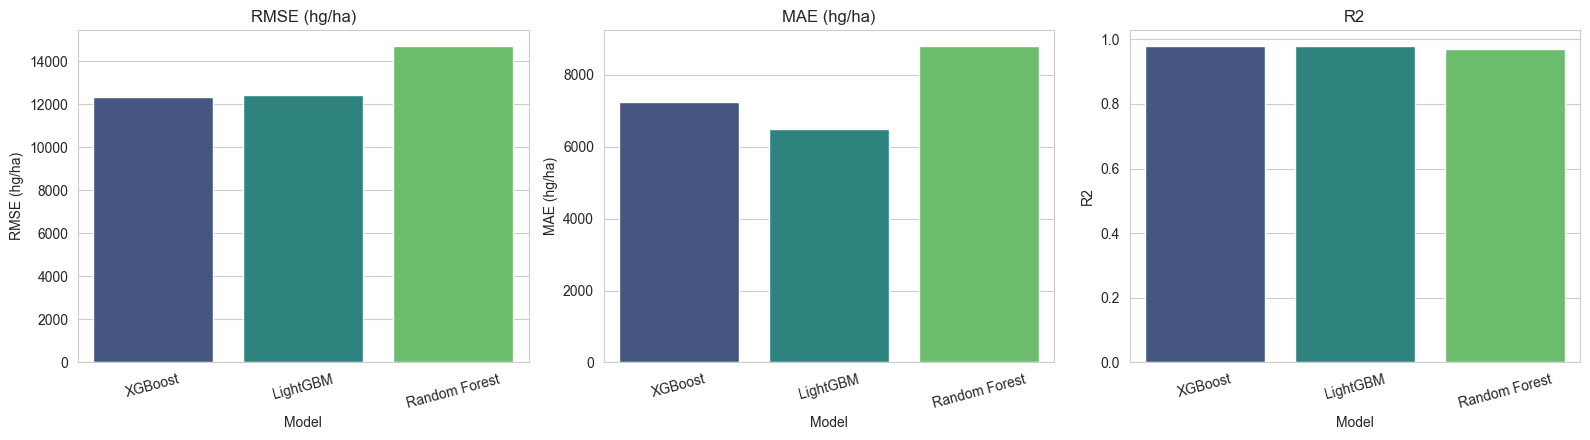

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["RMSE (hg/ha)", "MAE (hg/ha)", "R2"]):
    sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
savefig("06_model_comparison_metrics.png")
plt.show()


In [53]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]
print(f"🏆 Best model on test RMSE: {best_model_name}")
results_df


🏆 Best model on test RMSE: XGBoost


,Model,RMSE (hg/ha),MAE (hg/ha),R2
0,XGBoost,12321.228510,7233.263184,0.979071
1,LightGBM,12418.320086,6497.594212,0.978740
2,Random Forest,14705.042586,8797.817651,0.970189


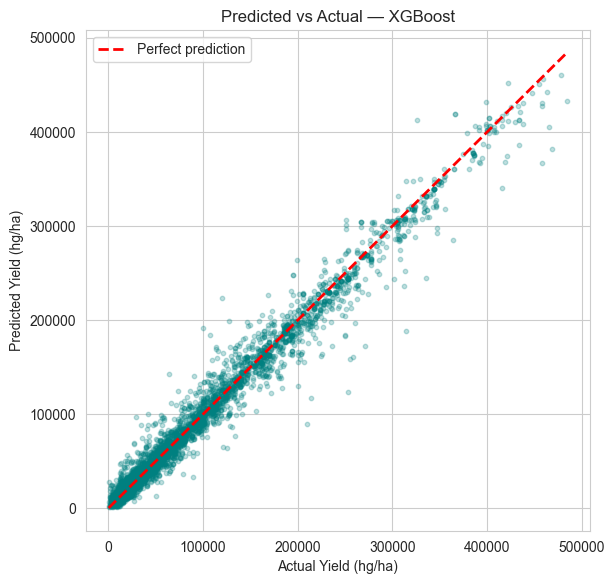

In [54]:
preds = best_pipeline.predict(X_test)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, preds, alpha=0.25, s=10, color="teal")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual Yield (hg/ha)")
plt.ylabel("Predicted Yield (hg/ha)")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
savefig("07_predicted_vs_actual.png")
plt.show()


In [55]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = -cross_val_score(best_pipeline, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"5-Fold CV RMSE: {cv_rmse.mean():,.0f} ± {cv_rmse.std():,.0f} hg/ha")


5-Fold CV RMSE: 12,104 ± 416 hg/ha


## 9. Feature Importance <a id='9'></a>

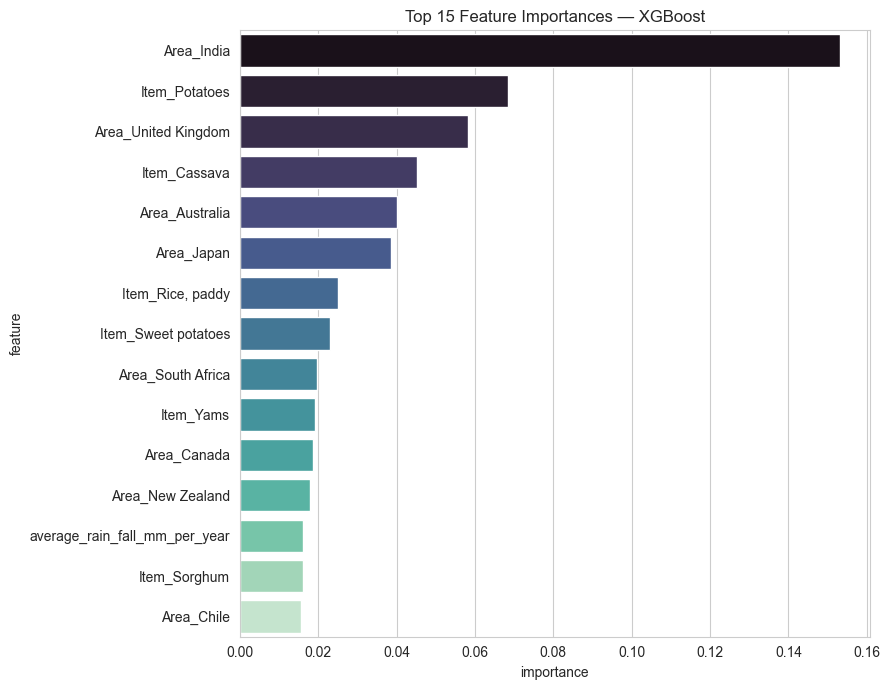

In [56]:
ohe = best_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_names)

importances = best_pipeline.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=fi_df, x="importance", y="feature", palette="mako")
plt.title(f"Top 15 Feature Importances — {best_model_name}")
plt.tight_layout()
savefig("08_feature_importance.png")
plt.show()


## 10. Hyperparameter Tuning (Best Model) <a id='10'></a>

A focused `GridSearchCV` around the best-performing model.


In [57]:
if best_model_name == "XGBoost":
    param_grid = {
        "model__n_estimators": [400, 600],
        "model__max_depth": [6, 8],
        "model__learning_rate": [0.05, 0.1],
    }
elif best_model_name == "LightGBM":
    param_grid = {
        "model__n_estimators": [400, 600],
        "model__num_leaves": [63, 127],
        "model__learning_rate": [0.05, 0.1],
    }
else:
    param_grid = {
        "model__n_estimators": [100, 150],
        "model__max_depth": [10, 14],
        "model__min_samples_leaf": [2, 4],
    }

grid_search = GridSearchCV(
    best_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
tuned_model = grid_search.best_estimator_

tuned_metrics = evaluate(tuned_model, X_test, y_test, f"{best_model_name} (tuned)")
print(tuned_metrics)


Best params: {'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 600}
{'Model': 'XGBoost (tuned)', 'RMSE (hg/ha)': np.float64(9471.877532992074), 'MAE (hg/ha)': 4683.853515625, 'R2': 0.9876315593719482}


In [58]:
baseline_rmse = results_df.iloc[0]["RMSE (hg/ha)"]
final_model = tuned_model if tuned_metrics["RMSE (hg/ha)"] <= baseline_rmse else best_pipeline
print("Using:", "tuned model" if final_model is tuned_model else "original best model")


Using: tuned model


## 11. Save Final Model for Deployment <a id='11'></a>


In [60]:
MODEL_PATH = os.path.join(MODEL_DIR, "crop_yield_model.pkl")
joblib.dump(final_model, MODEL_PATH)

metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
    "target_unit": "hg/ha",
    "model_name": best_model_name,
    "test_rmse": float(min(baseline_rmse, tuned_metrics["RMSE (hg/ha)"])),
    "test_mae": float(tuned_metrics["MAE (hg/ha)"] if final_model is tuned_model else results_df.iloc[0]["MAE (hg/ha)"]),
    "test_r2": float(tuned_metrics["R2"] if final_model is tuned_model else results_df.iloc[0]["R2"]),
    "countries": sorted(df["Area"].unique().tolist()),
    "crops": sorted(df["Item"].unique().tolist()),
    "year_min": int(df["Year"].min()),
    "year_max": int(df["Year"].max()),
}
joblib.dump(metadata, os.path.join(MODEL_DIR, "model_metadata.pkl"))

print("Saved model to:", MODEL_PATH)
print({k: v for k, v in metadata.items() if k not in ("countries", "crops")})


Saved model to: ../models\crop_yield_model.pkl
{'numeric_features': ['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes', 'log_pesticides', 'temp_rain_interaction', 'Year', 'years_since_1990'], 'categorical_features': ['Area', 'Item'], 'target': 'hg/ha_yield', 'target_unit': 'hg/ha', 'model_name': 'XGBoost', 'test_rmse': 9471.877532992074, 'test_mae': 4683.853515625, 'test_r2': 0.9876315593719482, 'year_min': 1990, 'year_max': 2013}


## 12. Inference Demo — Single Prediction <a id='12'></a>

Mirrors what the FastAPI `/predict` endpoint and Streamlit form do internally.


In [61]:
sample = pd.DataFrame([{
    "Area": "India",
    "Item": "Wheat",
    "Year": 2024,
    "average_rain_fall_mm_per_year": 1100,
    "avg_temp": 24.5,
    "pesticides_tonnes": 45000,
}])

sample_fe = engineer_features(sample)
feature_cols = numeric_features + categorical_features
pred_hg_ha = final_model.predict(sample_fe[feature_cols])[0]
pred_tonnes_ha = pred_hg_ha / 100_000
print(f"🌱 Predicted yield: {pred_hg_ha:,.0f} hg/ha  (≈ {pred_tonnes_ha:.2f} tonnes/ha)")


🌱 Predicted yield: 28,830 hg/ha  (≈ 0.29 tonnes/ha)



---
### Run the deployment layer

```bash
# FastAPI (from project root)
cd api
uvicorn main:app --reload --port 8000
# then open http://127.0.0.1:8000/docs

# Streamlit (from project root, in another terminal)
cd app
streamlit run streamlit_app.py
```
